<a href="https://colab.research.google.com/github/HuanNguyen213421345/thuvien/blob/main/_notebooks/2020-10-24-Support%20Vector%20Regression%20(SVR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Regression (SVR)

> A tutorial on How to use SVR.

- toc: true
- badges: true
- comments: true
- categories: [jupyter, Regression]

## 0. Data Preprocessing

In [15]:
from google.colab import files
uploaded = files.upload()

Saving dataset_csv.zip to dataset_csv.zip


In [17]:
import zipfile

with zipfile.ZipFile("dataset_csv.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset_csv")


In [18]:
import os

os.listdir("dataset_csv")

['dataset.csv']

### 0.1 Importing the libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

### 0.2 Importing the dataset

In [22]:
train1 = pd.read_csv("dataset_csv/dataset.csv/train_Bearing1_1.csv")

train2 = pd.read_csv("dataset_csv/dataset.csv/train_Bearing1_2.csv")

train3 = pd.read_csv("dataset_csv/dataset.csv/train_Bearing1_3.csv")

train4 = pd.read_csv("dataset_csv/dataset.csv/train_Bearing1_4.csv")

test = pd.read_csv("dataset_csv/dataset.csv/train_Bearing1_5.csv")

In [28]:
train_df = pd.concat(

    [train1, train2, train3, train4],

    ignore_index=True
)

### 0.3 Split into X & y

In [29]:
X_train = train_df.drop(columns=["RUL"]).values

y_train = train_df["RUL"].values


X_test = test.drop(columns=["RUL"]).values

y_test = test["RUL"].values

In [ ]:
y = y.reshape(len(y),1)

### 0.4 Feature Scaling

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## 1. Training the model on the whole dataset

In [34]:
model = SVR(

    kernel='rbf',

    C=10,

    gamma='scale',

    epsilon=0.01
)

model.fit(

    X_train_scaled,

    y_train
)

SVR(C=10, epsilon=0.01)

## 2. Predicting a new result with SVR

In [36]:
y_pred = model.predict(X_test_scaled)

In [37]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)

print("MAE:", mae)

print("R2:", r2)

RMSE: 0.3590104466339258
MAE: 0.29510891809562373
R2: -0.48829740537513255


## 3. Visualising the SVR results

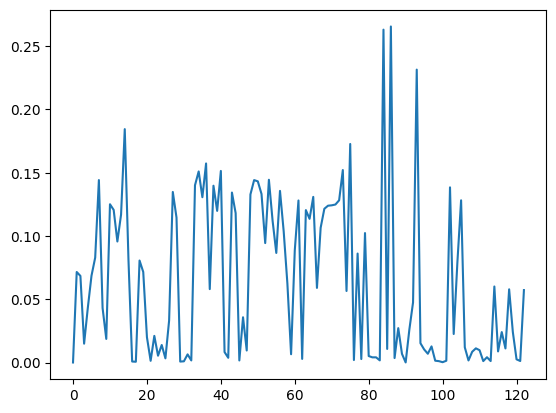

In [39]:
plt.plot(train1["RMS"])